# Mobile Games A/B Testing - Cookie Cats


## Business Context

### Business Problem

Cookie Cats is a mobile game in which players encounter a gate that limits their progression through the game.

The experiment tests whether moving the first gate from level 30 to level 40 affects player engagement and retention.

Players were randomly assigned to one of two versions:

- **Control group (gate_30)** — the first gate appears at level 30
- **Treatment group (gate_40)** — the first gate appears at level 40

The goal is to determine whether changing the gate position leads to a meaningful difference in player retention.

### Business Question

> **Does moving the first gate from level 30 to level 40 improve player retention?**

### Primary Metric

**D7 Retention** - the proportion of players who return to the game seven days after installation.

D7 retention is treated as the primary success metric because it captures longer-term engagement than D1 retention.

### Secondary Metric

**D1 Retention** - the proportion of players who return to the game one day after installation.

### Supporting Engagement Metric

**Total Game Rounds** - the total number of game rounds played by each user.

This metric is used to understand whether the gate position is associated with differences in player engagement.

### Hypotheses

For D7 retention:

- **H0 (Null Hypothesis):** There is no difference in D7 retention between the gate_30 and gate_40 groups.
- **H1 (Alternative Hypothesis):** D7 retention differs between the gate_30 and gate_40 groups.


## Data Loading & Data Quality

### Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import confint_proportions_2indep, proportion_effectsize
import statsmodels.stats.power as sms

In [2]:
import kagglehub

path = kagglehub.dataset_download("yufengsui/mobile-games-ab-testing")
print("Path to dataset files:", path)

100%|██████████| 490k/490k [00:00<00:00, 55.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yufengsui/mobile-games-ab-testing/versions/1


In [3]:
import os
os.listdir(path)

['cookie_cats.csv']

In [4]:
file_path = f"{path}/cookie_cats.csv"

df = pd.read_csv(file_path)
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### Data Quality

In [5]:
df.shape

(90189, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
userid,90189.0,NaN,NaN,NaN,4998412.234496,2883285.6077,116.0,2512230.0,4995815.0,7496452.0,9999861.0
version,90189,2,gate_40,45489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sum_gamerounds,90189.0,NaN,NaN,NaN,51.872457,195.050858,0.0,5.0,16.0,51.0,49854.0
retention_1,90189,2,False,50036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retention_7,90189,2,False,73408,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

,0
userid,90189
version,2
sum_gamerounds,942
retention_1,2
retention_7,2


In [10]:
df['version'].value_counts()

,count
version,
gate_40,45489
gate_30,44700


The dataset contains 90 189 unique players with no missing values and no duplicate records.

The experiment groups are closely balanced:

- gate_30: 44 700 players
- gate_40: 45 489 players


The 'sum_gamerounds' variable is highly right-skewed. The median player completed 16 rounds, compared with a mean of 51.9 rounds. The maximum value of 49 854 rounds indicates the presence of an extreme high-engagement user. And the minimum value is 0.

### Group Balance

In [11]:
group_share = df['version'].value_counts().reset_index(name='players')
group_share

,version,players
0,gate_40,45489
1,gate_30,44700


In [12]:
group_share['share'] = round(group_share['players'] / group_share['players'].sum() * 100, 2)
group_share

,version,players,share
0,gate_40,45489,50.44
1,gate_30,44700,49.56


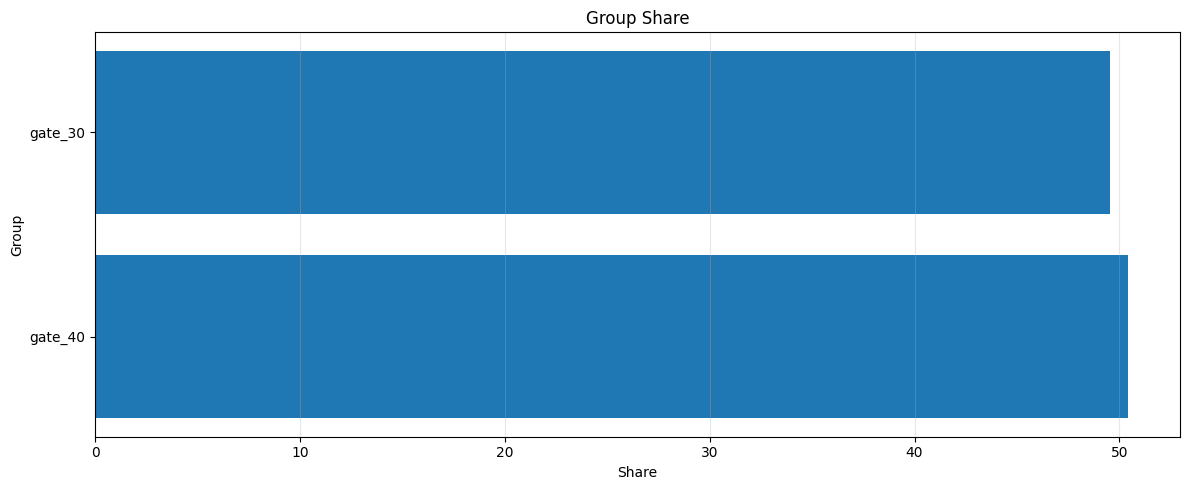

In [13]:
plt.figure(figsize=(12,5))

plt.barh(group_share['version'], group_share['share'])
plt.title('Group Share')
plt.xlabel('Share')
plt.ylabel('Group')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

The experiment was expected to assign users approximately equally between the two variants.

The observed allocation is:

- gate_30: 44 700 users (49.56%)
- gate_40: 45 489 users (50.44%)

Although the groups appear almost perfectly balanced, we should formally test whether this deviation from the expected 50/50 allocation is statistically significant.

To assess whether the observed allocation is consistent with the expected 50/50 split, we perform a Chi-square test.

H0: The observed group allocation follows the expected 50/50 distribution.

H1: The observed group allocation differs from the expected 50/50 distribution.

We use alpha = 0.05.

In [14]:
group_count = df['version'].value_counts()
group_count

,count
version,
gate_40,45489
gate_30,44700


In [15]:
# Chi-square test
observed = [group_count['gate_40'], group_count['gate_30']]
expected = [len(df) * 0.5, len(df) * 0.5]
alpha = 0.05

chi2_stat, p_val = stats.chisquare(f_obs=observed, f_exp=expected)
print(f"Chi2: {chi2_stat:.4f}, P-value: {p_val:.4f}")

if p_val < alpha:
  print('The observed group allocation significantly differs from the expected 50/50 split (H1)')
else: print('No statistically significant deviation from the expected 50/50 split was detected(H0)')

Chi2: 6.9024, P-value: 0.0086
The observed group allocation significantly differs from the expected 50/50 split (H1)


The chi-square test showed a statistically significant deviation from the expected 50/50 allocation (p = 0.0086), so we reject the null hypothesis that the groups are distributed equally. However, the actual difference is very small: 49.56% of users were assigned to gate_30 and 50.44% to gate_40, representing only a 0.44 percentage-point deviation from the expected share.

Therefore, although the imbalance is statistically significant, it is unlikely to be practically meaningful. We will keep this minor imbalance in mind when interpreting the A/B test results.

### Game rounds

In [16]:
df[['userid', 'version', 'sum_gamerounds']].sort_values('sum_gamerounds', ascending=False).head(5)

,userid,version,sum_gamerounds
57702,6390605,gate_30,49854
7912,871500,gate_30,2961
29417,3271615,gate_40,2640
43671,4832608,gate_30,2438
48188,5346171,gate_40,2294


In [17]:
df['sum_gamerounds'].describe()

,sum_gamerounds
count,90189.000000
mean,51.872457
std,195.050858
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,49854.000000


In [18]:
df_without_outlier = df[df['sum_gamerounds'] < 49854]
df_without_outlier['sum_gamerounds'].describe()

,sum_gamerounds
count,90188.000000
mean,51.320253
std,102.682719
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,2961.000000


Although the dataset contains one extreme outlier with 49 854 game rounds, which is substantially higher than the second-highest observation (2 961 rounds), removing this observation has a negligible effect on the main descriptive statistics.

After removing the outlier, the arithmetic mean decreases from 51.87 to 51.32 rounds - a difference of only 0.55 rounds. The median and both the 25th and 75th percentiles remain unchanged.

Therefore, we retain this user in the dataset. However, we will keep this extreme observation in mind when selecting and interpreting metrics throughout the analysis, particularly for engagement-related metrics.

## Exploratory Analysis

### Game Rounds Distribution

In [19]:
df['sum_gamerounds'].describe()

,sum_gamerounds
count,90189.000000
mean,51.872457
std,195.050858
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,49854.000000


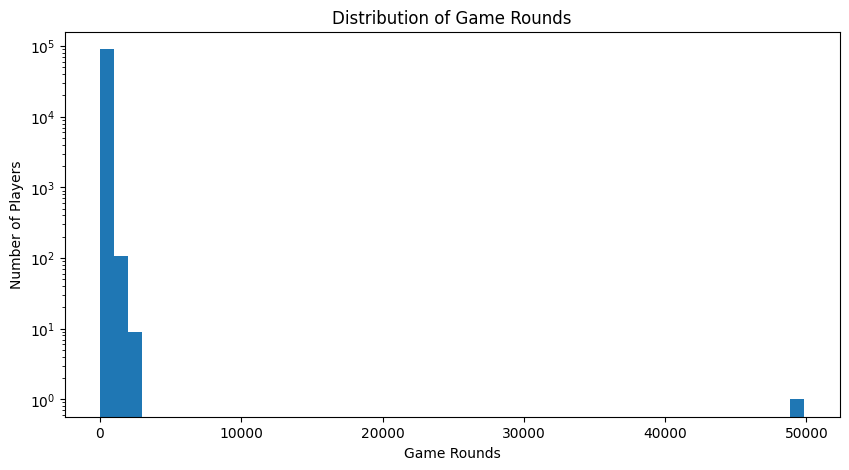

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(df['sum_gamerounds'], bins=50)

plt.xlabel('Game Rounds')
plt.ylabel('Number of Players')
plt.title('Distribution of Game Rounds')

plt.yscale('log')

plt.show()

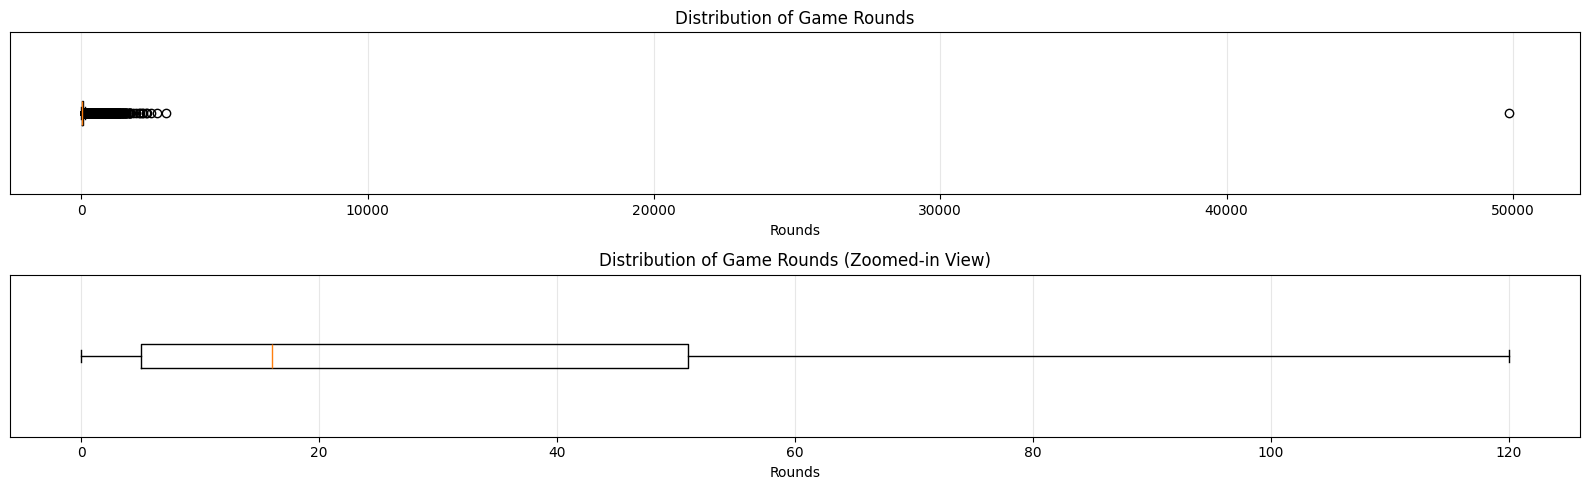

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(df['sum_gamerounds'],vert=False)
ax[0].set_title("Distribution of Game Rounds")
ax[0].set_xlabel("Rounds")
ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([])

ax[1].boxplot(df['sum_gamerounds'],vert=False, showfliers=False)
ax[1].set_title("Distribution of Game Rounds (Zoomed-in View)")
ax[1].set_xlabel("Rounds")
ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

In [22]:
print(f"Median: {df['sum_gamerounds'].median()} rounds")
print(f"Average: {df['sum_gamerounds'].mean():.1f} rounds")
print(f"75th percentile: {df['sum_gamerounds'].quantile(0.75)} rounds")
print(f"90th percentile: {df['sum_gamerounds'].quantile(0.9)} rounds")
print(f"95th percentile: {df['sum_gamerounds'].quantile(0.95)} rounds")
print(f"99th percentile: {df['sum_gamerounds'].quantile(0.99)} rounds")

Median: 16.0 rounds
Average: 51.9 rounds
75th percentile: 51.0 rounds
90th percentile: 134.0 rounds
95th percentile: 221.0 rounds
99th percentile: 493.0 rounds


The distribution of game rounds is strongly right-skewed.

The median player played only 16 rounds, while the middle 50% of players played between 5 and 51 rounds.

At the same time, the mean is substantially higher at 51.9 rounds because the relatively small number of highly active players pulls the average upward.

The percentile analysis further highlights the long right tail: 25% of players played more than 51 rounds, 10% played more than 134 rounds, 5% played more than 221 rounds, and 1% played more than 493 rounds.

### Game Rounds: Mann-Whitney U test & Descriptive Comparison

Because 'sum_gamerounds' is strongly right-skewed (not normal), we use the Mann-Whitney U test to compare the distributions of game rounds between the two experiment groups.

H0: There is no statistically significant difference between the distributions of game rounds in the two groups.

H1: The distributions of game rounds differ between the two groups.

A significance level of a = 0.05.

In [23]:
# mann-whitney
gate_30 = df.loc[df['version'] == 'gate_30', 'sum_gamerounds']
gate_40 = df.loc[df['version'] == 'gate_40', 'sum_gamerounds']
alpha = 0.05

u_stat, p_value = stats.mannwhitneyu(gate_30, gate_40)
print(f'U-statistics:{u_stat}, p-value:{p_value}')
if p_value < alpha:
  print('The distributions of game rounds significantly differ between the two groups (H1)')
else: print('No statistically significant deviation from the distributions of game rounds between gate_30 and gate_40.(H0)')

U-statistics:1024331250.5, p-value:0.05020880772044255
No statistically significant deviation from the distributions of game rounds between gate_30 and gate_40.(H0)


In [24]:
group_stats = df.groupby('version')['sum_gamerounds'].agg(['mean', 'median', 'min', 'max'])

p90 = df.groupby('version')['sum_gamerounds'].quantile(0.9)
p95 = df.groupby('version')['sum_gamerounds'].quantile(0.95)
p99 = df.groupby('version')['sum_gamerounds'].quantile(0.99)

group_stats['p95'] = p95
group_stats['p99'] = p99

group_stats.round(1)

,mean,median,min,max,p95,p99
version,,,,,,
gate_30,52.5,17.0,0,49854,222.0,493.0
gate_40,51.3,16.0,0,2640,220.0,492.1


The p-value (0.0502) is very close to the threshold of 0.05 - this is a borderline result. Although, from a technical standpoint, we cannot reject the null hypothesis H0, the difference in engagement between the groups should be considered inconclusive.

The descriptive statistics also show very similar values: the median is 17 rounds for gate_30 and 16 for gate_40, while P95 and P99 are almost identical. The slightly higher mean in gate_30 (52.5 vs. 51.3) can be driven by the extreme outlier of 49 854 rounds, which belongs to this group.

I also suggest reanalyzing this same sample without our large outlier to determine whether it affects our results.

In [25]:
# mann-whitney without oulier
gate_30 = df_without_outlier.loc[df_without_outlier['version'] == 'gate_30', 'sum_gamerounds']
gate_40 = df_without_outlier.loc[df_without_outlier['version'] == 'gate_40', 'sum_gamerounds']
alpha = 0.05

u_stat, p_value = stats.mannwhitneyu(gate_30, gate_40)
print(f'U-statistics:{u_stat}, p-value:{p_value}')
if p_value < alpha:
  print('The distributions of game rounds significantly differ between the two groups (H1)')
else: print('No statistically significant deviation from the distributions of game rounds between gate_30 and gate_40.(H0)')

U-statistics:1024285761.5, p-value:0.05089155279145376
No statistically significant deviation from the distributions of game rounds between gate_30 and gate_40.(H0)


In [26]:
group_stats = df_without_outlier.groupby('version')['sum_gamerounds'].agg(['mean', 'median', 'min', 'max'])
group_stats

,mean,median,min,max
version,,,,
gate_30,51.342111,17.0,0,2961
gate_40,51.298776,16.0,0,2640


We hypothesized that our outlier (49 854 rounds) might have artificially pushed the p-value toward the significance threshold, so we decided to test this by recalculating the test without it. The p-value remained almost unchanged (0.0509 vs. 0.0502) meaning that our borderline result is not related to this single user but reflects the actual distribution of the data.

Therefore, I would describe the engagement result as inconclusive, with a slight descriptive tendency toward higher engagement in gate_30.

## Retention Analysis

### D1 Retention

In [27]:
df.head(2)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False


In [28]:
d1_retention = df.groupby('version')['retention_1'].agg(users='count', retained_D1='sum')

d1_retention['retained_D1_rate'] = d1_retention['retained_D1'] / d1_retention['users'] * 100

d1_retention

,users,retained_D1,retained_D1_rate
version,,,
gate_30,44700,20034,44.818792
gate_40,45489,20119,44.228275


D1 retention is a binary outcome: each player either returned on Day 1 or did not. Therefore, the metric is expressed as a proportion of retained players within each experiment group.

Since we are comparing this proportion between two independent groups (gate_30 and gate_40), a two-proportion z-test is appropriate for testing whether the observed difference in D1 retention is statistically significant.

H0: There is no statistically significant difference in D1 retention between the gate_30 and gate_40.

H1: There is a statistically significant difference in D1 retention between the gate_30 and gate_40.

A significance level of a = 0.05.

In [29]:
# 2 prop z-test
retained_30 = d1_retention.loc['gate_30', 'retained_D1']
retained_40 = d1_retention.loc['gate_40', 'retained_D1']

users_30 = d1_retention.loc['gate_30', 'users']
users_40 = d1_retention.loc['gate_40', 'users']

alpha = 0.05

z_stat, p_value = sm.stats.proportions_ztest([retained_30, retained_40], [users_30, users_40])

print(f'Z-statistics: {z_stat}, p_value: {p_value}')
if p_value < alpha:
  print('D1 retention significantly differ between the two groups (H1)')
else: print('No statistically significant difference in D1 retention between gate_30 and gate_40.(H0)')

Z-statistics: 1.7840862247974725, p_value: 0.07440965529691913
No statistically significant difference in D1 retention between gate_30 and gate_40.(H0)


D1 retention is very similar between the two experiment groups: 44.82% for gate_30 and 44.23% for gate_40, a difference of only 0.59 percentage points.

Z-test resulted in a p-value of 0.0744, which is above the 0.05 significance threshold. Therefore, we fail to reject the null hypothesis and find no statistically significant evidence that changing the gate from 30 to 40 affects D1 retention.

### D7 Retention

In [30]:
d7_retention = df.groupby('version')['retention_7'].agg(users='count', retained_D7='sum')

d7_retention['retained_D7_rate'] = d7_retention['retained_D7'] / d7_retention['users'] * 100

d7_retention

,users,retained_D7,retained_D7_rate
version,,,
gate_30,44700,8502,19.020134
gate_40,45489,8279,18.200004


H0: There is no statistically significant difference in D7 retention between the gate_30 and gate_40.

H1: There is a statistically significant difference in D7 retention between the gate_30 and gate_40.

A significance level of a = 0.05.

In [31]:
# 2 prop z-test
retained_30 = d7_retention.loc['gate_30', 'retained_D7']
retained_40 = d7_retention.loc['gate_40', 'retained_D7']

users_30 = d7_retention.loc['gate_30', 'users']
users_40 = d7_retention.loc['gate_40', 'users']

alpha = 0.05

z_stat, p_value = sm.stats.proportions_ztest([retained_30, retained_40], [users_30, users_40])

print(f'Z-statistics: {z_stat}, p_value: {p_value}')
if p_value < alpha:
  print('D7 retention significantly differ between the two groups (H1)')
else: print('No statistically significant difference in D7 retention between gate_30 and gate_40.(H0)')

Z-statistics: 3.164358912748191, p_value: 0.001554249975614329
D7 retention significantly differ between the two groups (H1)


D7 retention is higher in the gate_30 group than in the gate_40 group: 19.02% vs. 18.20%, corresponding to a difference of 0.82 percentage points.

Z-test produced a p-value of 0.00155, which is below the significance level of a = 0.05. Therefore, we reject H0 and conclude that the difference in D7 retention between the two groups is statistically significant.

This suggests that keeping the gate at 30 is associated with higher D7 retention compared with moving the gate to 40.

### D1 vs D7 comparison

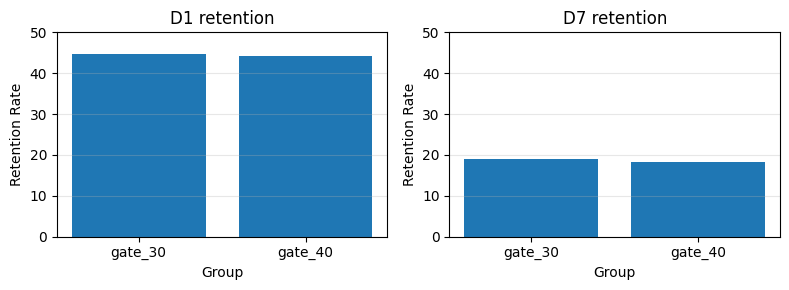

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

# D1
ax[0].bar(
    d1_retention.index,
    d1_retention['retained_D1_rate'])
ax[0].set_title('D1 retention')
ax[0].set_xlabel('Group')
ax[0].set_ylabel('Retention Rate')
ax[0].tick_params(axis='x', rotation=0)
ax[0].grid(axis="y", alpha=0.3)
ax[0].set_ylim(0, 50)

# D2
ax[1].bar(
    d7_retention.index,
    d7_retention['retained_D7_rate'])
ax[1].set_title('D7 retention')
ax[1].set_xlabel('Group')
ax[1].set_ylabel('Retention Rate')
ax[1].tick_params(axis='x', rotation=0)
ax[1].grid(axis="y", alpha=0.3)
ax[1].set_ylim(0, 50)

plt.tight_layout()
plt.show()

D1 retention is nearly identical between the two groups, while D7 retention shows a clearer difference in favor of gate_30. This visual pattern is consistent with the statistical test results: the D1 difference is not statistically significant, whereas the D7 difference is statistically significant.

## Statistical Testing - D7 Confirmatory

### Difference in proportion

In [33]:
gate_30_rate = d7_retention.loc['gate_30', 'retained_D7_rate']
gate_40_rate = d7_retention.loc['gate_40', 'retained_D7_rate']

absolute_diff = round(gate_30_rate - gate_40_rate, 2)
relative_diff = round(((gate_40_rate - gate_30_rate) / gate_30_rate) * 100, 2)

print(f'Absolute difference in proportions: {absolute_diff}%')
print(f'Relative difference in proportions: {relative_diff}%')

Absolute difference in proportions: 0.82%
Relative difference in proportions: -4.31%


The absolute difference is 0.82%, meaning that 0.82 percentage points more users were retained on Day 7 in the gate_30 group.

The relative difference is approximately -4.31%, meaning that D7 retention in gate_40 is about 4.5% lover relative to gate_30.

### Z-test

In [34]:
# run z test from the previous section again
retained_30 = d7_retention.loc['gate_30', 'retained_D7']
retained_40 = d7_retention.loc['gate_40', 'retained_D7']

users_30 = d7_retention.loc['gate_30', 'users']
users_40 = d7_retention.loc['gate_40', 'users']

alpha = 0.05

z_stat, p_value = sm.stats.proportions_ztest([retained_30, retained_40], [users_30, users_40])

print(f'Z-statistics: {z_stat}, p_value: {p_value}')
if p_value < alpha:
  print('D7 retention significantly differ between the two groups (H1)')
else: print('No statistically significant difference in D7 retention between gate_30 and gate_40.(H0)')

Z-statistics: 3.164358912748191, p_value: 0.001554249975614329
D7 retention significantly differ between the two groups (H1)


### 95% Confidence Interval

The z-test tells us whether the difference in D7 retention is statistically significant, but not how large the true effect might be. The confidence interval estimates the range of plausible values for the true difference between gate_30 and gate_40, given the observed data.

We use 'confint_proportions_2indep' with the Wald method, appropriate given the large sample size in each group.

In [35]:
ci_low, ci_high = confint_proportions_2indep(
    count1=retained_30,
    nobs1=users_30,
    count2=retained_40,
    nobs2=users_40,
    method='wald'
)

print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

95% CI: [0.0031, 0.0133]


In [36]:
print(f"95% CI: [{ci_low * 100:.2f} pp, {ci_high * 100:.2f} pp]")

95% CI: [0.31 pp, 1.33 pp]


We obtained a range of 0.31 to 1.33 percentage points. This means that if we could repeat this experiment many times with new users, in 95% of cases the interval constructed in this way would cover the true difference in retention between gate_30 and gate_40.

Importantly, the entire interval is greater than zero which means we are confident not only that there is an effect, but also in its direction: gate_30 performs better.

## Bootstrap Analysis

The Wald method is only one way of estimating the confidence interval. As an additional robustness check, we use bootstrap resampling to estimate the distribution of the observed difference directly from our data.

We cannot repeat the experiment with new users, but we can repeatedly resample the users we already observed. For each bootstrap sample, we calculate the difference in D7 retention between gate_30 and gate_40. After repeating this process 10 000 times, we obtain a bootstrap distribution of the difference and use it to construct a 95% confidence interval.

The purpose of this bootstrap analysis is not to perform another hypothesis test, but to check whether the estimated effect and its uncertainty are consistent with the Wald confidence interval.

In [39]:
#D7 retention data
gate_30_d7 = df.loc[df['version'] == 'gate_30', 'retention_7']
gate_40_d7 = df.loc[df['version'] == 'gate_40', 'retention_7']

# Bootstrap func
def bootstrap_difference(data_1, data_2, n_iterations):
    differences = []

    for i in range(n_iterations):
        sample_1 = data_1.sample(frac=1, replace=True)    #frac=1 - same size as input
        sample_2 = data_2.sample(frac=1, replace=True)    #replace=True - repeating the same value

        difference = sample_1.mean() - sample_2.mean()    #dtype bool

        differences.append(difference)

    return differences

# Run bootstrap
bootstrap_diffs = bootstrap_difference(gate_30_d7, gate_40_d7, 10000)

# 95% Confidence Interval
bootstrap_ci = np.percentile(bootstrap_diffs, [2.5, 97.5])

# Diff
observed_difference = (gate_30_d7.mean() - gate_40_d7.mean())

print(f"Observed difference: {observed_difference * 100:.2f} pp")
print(f"Bootstrap 95% CI: [{bootstrap_ci[0] * 100:.2f} pp, {bootstrap_ci[1] * 100:.2f} pp]")


Observed difference: 0.82 pp
Bootstrap 95% CI: [0.31 pp, 1.33 pp]


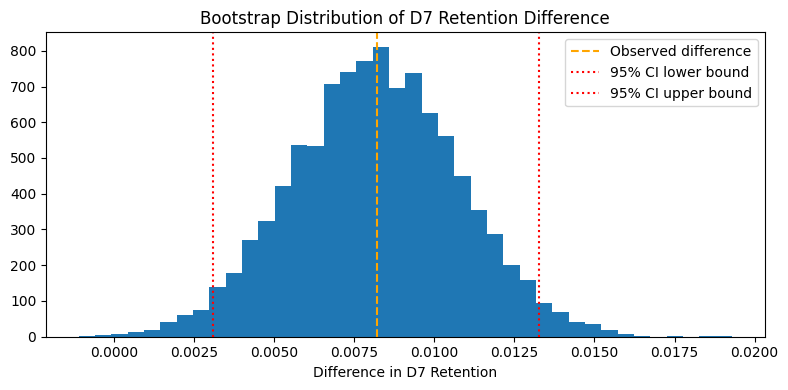

In [40]:
plt.figure(figsize=(8, 4))

plt.hist(bootstrap_diffs, bins=40)
plt.xlabel('Difference in D7 Retention')
plt.title('Bootstrap Distribution of D7 Retention Difference')

plt.axvline(observed_difference, linestyle='--', label='Observed difference', color='orange')
plt.axvline(bootstrap_ci[0], linestyle=':', label='95% CI lower bound', color='red')
plt.axvline(bootstrap_ci[1], linestyle=':', label='95% CI upper bound', color='red')

plt.legend()

plt.tight_layout()
plt.show()

Bootstrap analysis produced the same 95% confidence interval as the analytical Wald method: [+0.31 pp, +1.33 pp]. This confirms that the estimated uncertainty around the D7 retention difference is stable and not dependent on the analytical CI method used.

## Sample Size Analysis

### Baseline D7 Retention

The control group is 'gate_30', where the first gate appears at level 30.
Its observed D7 retention is 19.02%.

The treatment group is 'gate_40', where the first gate appears at level 40.
Its observed D7 retention is 18.20%.

Therefore, the observed difference is:

**18.20% − 19.02% = −0.82 percentage points.**

We use the control group's D7 retention (19.02%) as the baseline for the sample size and MDE analysis.

### Required Sample Size for Different Effect Sizes

In [41]:
# Baseline D7 retention - control group (gate_30)
baseline_retention = 0.1902

# Test parameters
alpha = 0.05
power = 0.8

# Expected lift
expected_lift = [0.0082, 0.01, 0.02, 0.03, 0.05]

results = []

for lift in expected_lift:

    # Expected treatment retention
    variant_retention = baseline_retention - lift

    # Effect size
    effect_size = proportion_effectsize(baseline_retention, variant_retention)

    # Required sample size per group
    sample_size = sms.NormalIndPower().solve_power(
        effect_size=effect_size, power=power, alpha=alpha, ratio=1)

    results.append({
        'Expected lift (pp)': lift * 100,
        'Control D7 (%)': baseline_retention * 100,
        'Treatment D7 (%)': variant_retention * 100,
        'Required sample per group': np.ceil(sample_size)})

lift_table = pd.DataFrame(results)

lift_table

,Expected lift (pp),Control D7 (%),Treatment D7 (%),Required sample per group
0,0.82,19.02,18.20,35358.0
1,1.00,19.02,18.02,23685.0
2,2.00,19.02,17.02,5794.0
3,3.00,19.02,16.02,2517.0
4,5.00,19.02,14.02,862.0


For the observed effect of 0.82 percentage points, the required sample size was approximately 35,358 users per group. Our actual sample was substantially larger (44 700 in control and 45 489 in treatment), indicating that the experiment was adequately sized to detect an effect of the observed magnitude with 80% power.

### Required Sample Size vs Effect Size chart

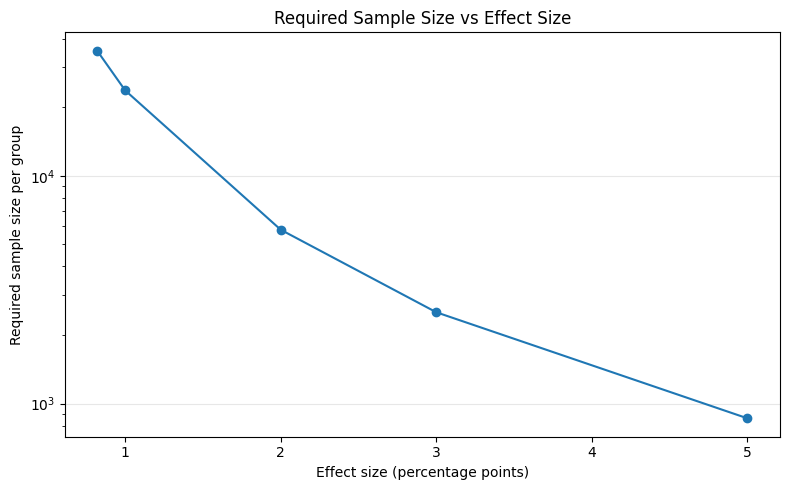

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(lift_table['Expected lift (pp)'], lift_table['Required sample per group'], marker='o')

plt.xlabel('Effect size (percentage points)')
plt.ylabel('Required sample size per group')
plt.title('Required Sample Size vs Effect Size')

plt.yscale('log')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In our case, to detect a small effect of 0.82 percentage points, we need approximately 35,358 users per group at a = 0.05 and power = 0.8. For larger effects, the required sample size decreases significantly.

## Data for dashboard

In [43]:
df.to_csv('ab_test_users.csv', index=False)

stats_summary = pd.DataFrame([{
    'gate_30_d7_rate': gate_30_rate, 'gate_40_d7_rate': gate_40_rate,
    'absolute_diff_pp': absolute_diff, 'relative_diff_pct': relative_diff,
    'z_stat': z_stat, 'p_value': p_value,
    'ci_low_pp': ci_low*100, 'ci_high_pp': ci_high*100,
    'bootstrap_ci_low_pp': bootstrap_ci[0]*100, 'bootstrap_ci_high_pp': bootstrap_ci[1]*100,
    'srm_chi2': chi2_stat, 'srm_p_value': p_val,
    'gate_30_share_pct': group_share.loc[group_share.version=='gate_30','share'].values[0],
    'gate_40_share_pct': group_share.loc[group_share.version=='gate_40','share'].values[0],
}])
stats_summary.to_csv('stats_summary.csv', index=False)


lift_table.to_csv('sample_size.csv', index=False)

In [ ]:
from google.colab import files

files.download('ab_test_users.csv')
files.download('stats_summary.csv')
files.download('sample_size.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Analysis logic

Ми почали з набору даних експерименту, у якому користувачі були випадковим чином розподілені між двома групами:

- **gate_30** - контрольна група, перший gate з'являється на 30 рівні;
- **gate_40** - тестова група, перший gate з'являється на 40 рівні.

Основною метрикою експерименту ми заздалегідь визначили **D7 retention**, другорядною - **D1 retention**, а кількість зіграних раундів використали як допоміжну метрику для оцінки engagement.

Спочатку ми перевірили якість даних. У датасеті було **90 189 унікальних користувачів**, без пропущених значень і дублікатів.

Далі ми перевірили, наскільки рівномірно користувачі розподілені між двома групами. Фактичний розподіл склав **44 700 користувачів у gate_30** та 4**5 489 у gate_40**, або **49.56% / 50.44%**.

За допомогою ксі квадрат тесту ми перевірили, чи відрізняється цей розподіл від ідеального 50/50. Тест показав статистично значуще відхилення (p = 0.0086). Однак практично це відхилення становить **лише 0.44 процентного пункту**, тому ми не вважаємо його суттєвим для подальшого аналізу.

Після цього ми дослідили розподіл кількості зіграних раундів. Дані виявилися сильно скошеними вправо. Також ми виявили екстремальне значення — користувач із **49 854 зіграними раундами**. Ми перевірили його вплив на описову статистику та побачили, що він практично не змінює медіану і лише незначно впливає на середнє. Тому ми вирішили не видаляти це спостереження.

Аналіз перцентилів показав, що медіанний користувач зіграв **16 раундів**, 75% користувачів зіграли до **51 раунду**, 90% - **до 134**, 95% - **до 221**, а 99% - **до 493 раундів**. Це підтверджує наявність невеликої групи дуже активних користувачів і сильну праву асиметрію розподілу.

Далі ми перевірили, чи відрізняється розподіл кількості зіграних раундів між **gate_30** та **gate_40**. Оскільки дані сильно скошені, ми використали непараметричний Mann-Whitney U test. Статистично значущої різниці між групами ми не виявили.

Це означає, **що ми не маємо статистичних підстав стверджувати, що зміна gate з 30 на 40 рівень змінила розподіл кількості зіграних раундів**.

Після цього ми перейшли до retention.

Спочатку перевірили **D1 retention**. У **gate_30** він склав **44.82%**, а в **gate_40** - **44.23%**. Різниця становила лише **0.59 п.п.**, а z-test дав p = 0.0744. Отже, **статистично значущої різниці в D1 retention між групами ми не виявили**.

Далі ми перейшли до нашої основної метрики - D7 retention.

У контрольній групі **gate_30 D7 retention склав 19.02%**, тоді як у **gate_40 - 18.20%**.

Абсолютна різниця становила **0.82 процентного пункту**, або приблизно **4.3% відносного зниження** порівняно з контрольною групою.

Z-test показав p = 0.00155, що значно нижче нашого рівня значущості a = 0.05. Тому ми **відкидаємо нульову гіпотезу** та маємо статистично значущі підстави вважати, що **D7 retention відрізняється між двома групами**.

Далі ми оцінили невизначеність нашої оцінки за допомогою 95% confidence interval. Wald CI для різниці склав приблизно **0.31–1.33 п.п.** за абсолютною величиною.

Щоб перевірити стійкість цієї оцінки, ми також використали bootstrap. Ми багаторазово пересемплювали наявні дані та щоразу розраховували різницю в D7 retention. Bootstrap дав такий самий 95% confidence interval - **0.31–1.33 п.п.**, що підтверджує стабільність нашої оцінки.

Нарешті, ми перевірили, чи був достатнім розмір вибірки для виявлення такого ефекту. Для виявлення різниці приблизно **0.82 п.п**. при a = 0.05 та statistical power = 0.8 потрібно було близько **35 358** користувачів на групу. Фактично у нас було 44 700 користувачів у меншій групі, тобто наш експеримент мав достатній розмір вибірки для виявлення ефекту такого масштабу.

Також ми побачили загальну закономірність: **чим менший ефект ми хочемо виявити, тим більша вибірка нам потрібна**.

### My Interpretation

Якщо головна мета - щоб користувачі поверталися в гру протягом якомога більшої кількості днів, то перенесення gate з 30 на 40 рівень за результатами цього експерименту виглядає невдалим рішенням.

Результати тесту підсвітили для мене можливий сценарій: коли користувачам встановлювали gate на 40 рівні замість 30, вони отримували більше доступних рівнів, але при цьому могли швидше дійти до своєї особистої "стелі" гри - моменту, коли подальше проходження ставало для них занадто складним або гра просто починала набридати. У такому випадку користувач міг швидше перестати повертатися до гри, що і могло призвести до нижчого D7 retention.


Якщо ж бізнес-мета полягає саме в тому, щоб користувачі проходили більше рівнів, то цей експеримент також не показав очікуваного ефекту: кількість зіграних раундів між групами статистично значуще не відрізнялася.

І саме цей результат змушує мене поставити наступне питання: чому gate 40 знижує D7 retention, якщо при цьому ми не бачимо статистично значущої різниці у кількості зіграних раундів?

Тому я вважаю що мій запропонований можлвий сценарій може бути однією з гіпотез для майбутніх тестувань

## Final Decision

За результатами цього A/B-тесту я б залишила gate на 30 рівні.

Головна причина дуже проста: наша primary metric - D7 retention, і саме вона статистично значуще погіршилася після перенесення gate на 40 рівень. При цьому ми не побачили статистично значущого покращення кількості зіграних раундів, яке могло б виправдати це падіння retention.